In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

train_df = pd.read_pickle(r"C:\CODING\Learn Python for Data Science FCC\Scikit - Learn\IEEE CIS Credit Card Fraud Detection\data\train.pkl")

In [2]:
train_df = train_df.sort_values(["Transaction_Day" , "Transaction_Time_Of_Day"]).reset_index(drop=True)

In [3]:
train_df.shape

(590540, 480)

In [4]:
split_idx = int(len(train_df))*0.8
train = train_df.loc[:split_idx]
val = train_df.loc[split_idx : ]

x_train = train.drop(columns=["isFraud" , "TransactionID" ,"TransactionDT"])
y_train = train["isFraud"]

x_val = val.drop(columns=["isFraud" , "TransactionID" , "TransactionDT"])
y_val = val["isFraud"]

In [5]:
numeric_cols = x_train.select_dtypes(include=["int64" , "float64" , "uint16" , "uint8"]).columns
categorical_cols = x_train.select_dtypes(include=["object"]).columns

In [6]:
# Initializing PIPELINE

In [7]:
# NUMERICAL

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median' , add_indicator=True)) ,
    ('scaler' , StandardScaler())
])

In [8]:
# CATEGORICAL

from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant' , fill_value="Missing")) ,
    ('encoder' , OneHotEncoder(handle_unknown='ignore'))
])

In [9]:
# COMBINED

from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('num' , numeric_pipeline , numeric_cols) ,
    ('cat' , categorical_pipeline , categorical_cols)
])

In [10]:
# Evaluation Function

In [11]:
from sklearn.metrics import (
    accuracy_score ,
    precision_score ,
    recall_score ,
    f1_score ,
    average_precision_score , 
    roc_auc_score ,
    confusion_matrix ,
    classification_report, 
    ConfusionMatrixDisplay ,
    RocCurveDisplay ,
    PrecisionRecallDisplay
)

In [12]:
def evaluate_model(model , x_train , y_train , x_val , y_val):

    # Train
    model.fit(x_train , y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)

    # Prob scores for ROC-AUC and curves
    y_train_prob = model.predict_proba(x_train)[:,1]
    y_val_prob = model.predict_proba(x_val)[:,1]

    # Metrices
    train_accuracy = accuracy_score(y_train , y_train_pred)
    val_accuracy = accuracy_score(y_val , y_val_pred)

    train_precision = precision_score(y_train , y_train_pred)
    val_precision = precision_score(y_val , y_val_pred)

    train_recall = recall_score(y_train , y_train_pred)
    val_recall = recall_score(y_val , y_val_pred)

    train_f1 = f1_score(y_train , y_train_pred)
    val_f1 = f1_score(y_val , y_val_pred)

    train_roc_auc = roc_auc_score(y_train , y_train_prob)
    val_roc_auc = roc_auc_score(y_val , y_val_prob)

    train_pr_auc = average_precision_score(y_train , y_train_prob)
    val_pr_auc = average_precision_score(y_val , y_val_prob)

    # Print Results
    print("TRAIN RESULTS")
    print("---------------")
    print(f"Accuracy = {train_accuracy:.4f}")
    print(f"Precision = {train_precision:.4f}")
    print(f"Recall = {train_recall:.4f}")
    print(f"F1 Score = {train_f1:.4f}")
    print(f"ROC-AUC = {train_roc_auc:.4f}")
    print(f"PR-AUC = {train_pr_auc:.4f}")

    print("\nVALIDATION RESULTS")
    print("---------------")    
    print(f"Accuracy = {val_accuracy:.4f}")
    print(f"Precision = {val_precision:.4f}")
    print(f"Recall = {val_recall:.4f}")
    print(f"F1 Score = {val_f1:.4f}")
    print(f"ROC-AUC = {val_roc_auc:.4f}")    
    print(f"PR-AUC = {val_pr_auc:.4f}")
    
    # Confusion Matrices
    print("\nTRAIN CONFUSION MATRIX")
    print(confusion_matrix(y_train , y_train_pred))

    print("\nVALIDATION CONFUSION MATRIX")
    print(confusion_matrix(y_val , y_val_pred))

    # ROC Curves
    plt.figure()

    RocCurveDisplay.from_predictions(y_train, y_train_prob , name="Train")
    RocCurveDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("ROC Curve")
    plt.show()

    # Precision-Recall curves
    plt.figure()

    PrecisionRecallDisplay.from_predictions(y_train, y_train_prob , name="Train")
    PrecisionRecallDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("Precision-Recall Curve")
    plt.show()    

    # Confusion Matrix plots
    fig , ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred , ax=ax)
    ax.set_title("Validation Confusion Matrix")
    plt.show()

In [13]:
## Model Evaluation

In [14]:
# XGboost model

from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42 , n_jobs=-1 , max_depth=10 , n_estimators=100))
])

TRAIN RESULTS
---------------
Accuracy = 0.9876
Precision = 0.9640
Recall = 0.6728
F1 Score = 0.7925
ROC-AUC = 0.9784
PR-AUC = 0.8731

VALIDATION RESULTS
---------------
Accuracy = 0.9733
Precision = 0.7151
Recall = 0.3718
F1 Score = 0.4892
ROC-AUC = 0.9051
PR-AUC = 0.5176

TRAIN CONFUSION MATRIX
[[455416    417]
 [  5431  11169]]

VALIDATION CONFUSION MATRIX
[[113442    602]
 [  2553   1511]]


<Figure size 640x480 with 0 Axes>

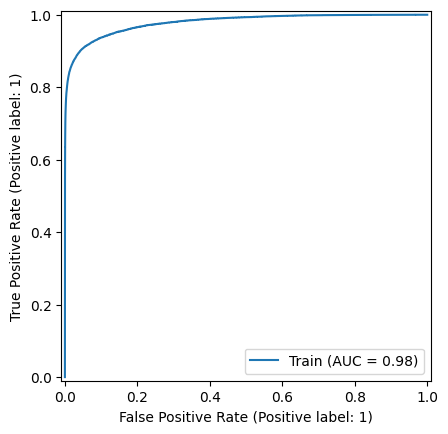

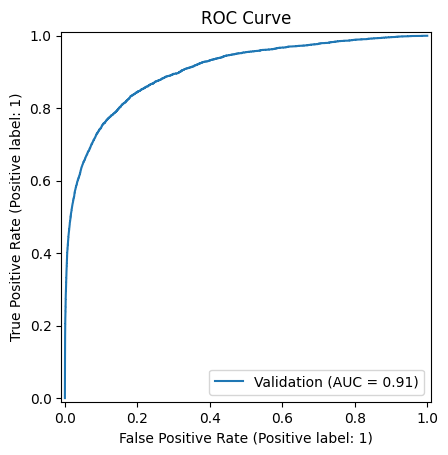

<Figure size 640x480 with 0 Axes>

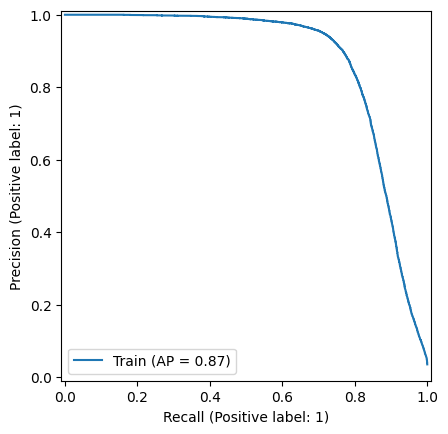

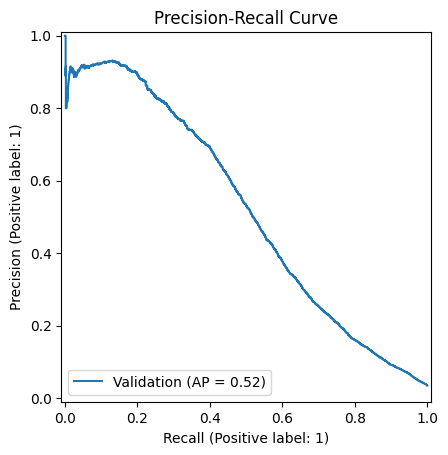

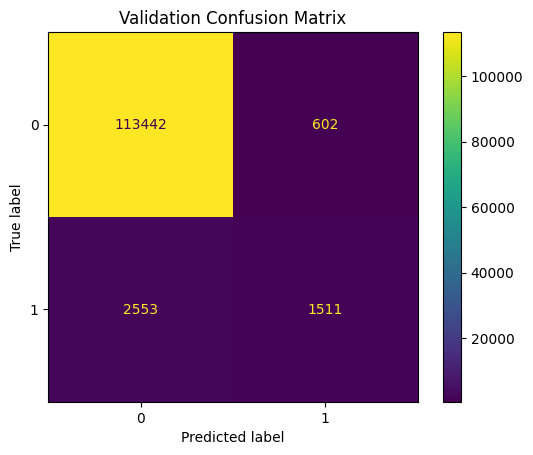

In [15]:
evaluate_model(xgb_pipeline , x_train , y_train , x_val , y_val)

In [16]:
# LightGBM

In [17]:
from lightgbm import LGBMClassifier

lgbmc_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , LGBMClassifier( objective="binary" , random_state=42 , n_jobs=-1 , max_depth=-1 , n_estimators=100 , learning_rate = 0.05 ,subsample=0.8 ,min_child_weight = 5, 
            num_leaves=31 , colsample_bytree = 0.8, reg_alpha = 0.0, reg_lambda = 0.0 , min_child_samples=20))
])

[LightGBM] [Info] Number of positive: 16600, number of negative: 455833
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 72.929557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 72229
[LightGBM] [Info] Number of data points in the train set: 472433, number of used features: 18652
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035137 -> initscore=-3.312724
[LightGBM] [Info] Start training from score -3.312724


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


TRAIN RESULTS
---------------
Accuracy = 0.9785
Precision = 0.9149
Recall = 0.4264
F1 Score = 0.5817
ROC-AUC = 0.9264
PR-AUC = 0.6728

VALIDATION RESULTS
---------------
Accuracy = 0.9736
Precision = 0.7928
Recall = 0.3164
F1 Score = 0.4523
ROC-AUC = 0.8947
PR-AUC = 0.5098

TRAIN CONFUSION MATRIX
[[455175    658]
 [  9522   7078]]

VALIDATION CONFUSION MATRIX
[[113708    336]
 [  2778   1286]]


<Figure size 640x480 with 0 Axes>

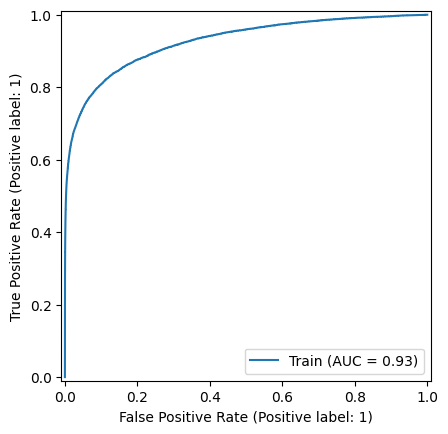

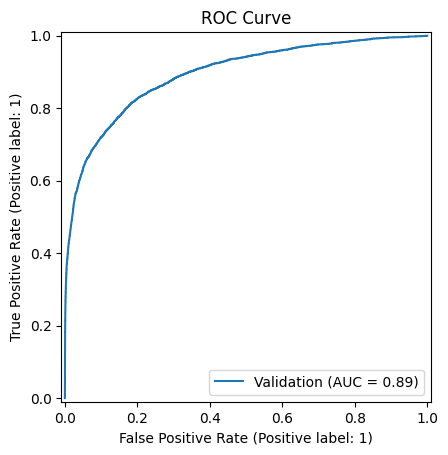

<Figure size 640x480 with 0 Axes>

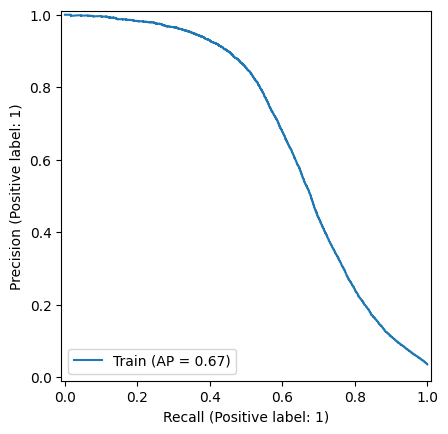

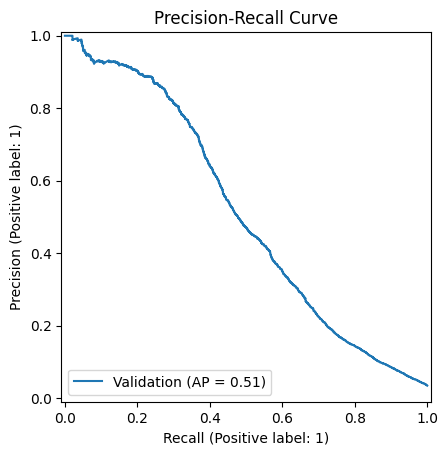

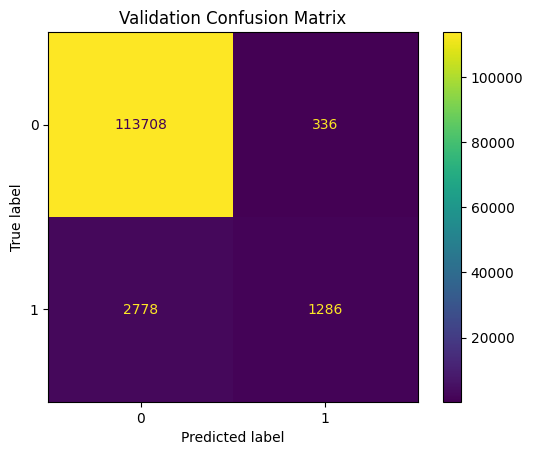

In [18]:
evaluate_model(lgbmc_pipeline , x_train , y_train , x_val , y_val)

In [19]:
# Catboost Model

In [20]:
x_train[categorical_cols] = x_train[categorical_cols].fillna("Missing")
x_val[categorical_cols] = x_val[categorical_cols].fillna("Missing")

In [21]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(iterations=300 , learning_rate=0.05 , depth=6 , loss_function="Logloss" , eval_metric="AUC",
                                random_seed=42 , verbose=100)

In [22]:
def evaluate_catboost_model(model , x_train , y_train , x_val , y_val):

    # Train
    model.fit(x_train , y_train , cat_features = categorical_cols.tolist())

    # Predictions
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)

    # Prob scores for ROC-AUC and curves
    y_train_prob = model.predict_proba(x_train)[:,1]
    y_val_prob = model.predict_proba(x_val)[:,1]

    # Metrices
    train_accuracy = accuracy_score(y_train , y_train_pred)
    val_accuracy = accuracy_score(y_val , y_val_pred)

    train_precision = precision_score(y_train , y_train_pred)
    val_precision = precision_score(y_val , y_val_pred)

    train_recall = recall_score(y_train , y_train_pred)
    val_recall = recall_score(y_val , y_val_pred)

    train_f1 = f1_score(y_train , y_train_pred)
    val_f1 = f1_score(y_val , y_val_pred)

    train_roc_auc = roc_auc_score(y_train , y_train_prob)
    val_roc_auc = roc_auc_score(y_val , y_val_prob)

    train_pr_auc = average_precision_score(y_train , y_train_prob)
    val_pr_auc = average_precision_score(y_val , y_val_prob)

    # Print Results
    print("TRAIN RESULTS")
    print("---------------")
    print(f"Accuracy = {train_accuracy:.4f}")
    print(f"Precision = {train_precision:.4f}")
    print(f"Recall = {train_recall:.4f}")
    print(f"F1 Score = {train_f1:.4f}")
    print(f"ROC-AUC = {train_roc_auc:.4f}")
    print(f"PR-AUC = {train_pr_auc:.4f}")

    print("\nVALIDATION RESULTS")
    print("---------------")    
    print(f"Accuracy = {val_accuracy:.4f}")
    print(f"Precision = {val_precision:.4f}")
    print(f"Recall = {val_recall:.4f}")
    print(f"F1 Score = {val_f1:.4f}")
    print(f"ROC-AUC = {val_roc_auc:.4f}")    
    print(f"PR-AUC = {val_pr_auc:.4f}")
    
    # Confusion Matrices
    print("\nTRAIN CONFUSION MATRIX")
    print(confusion_matrix(y_train , y_train_pred))

    print("\nVALIDATION CONFUSION MATRIX")
    print(confusion_matrix(y_val , y_val_pred))

    # ROC Curves
    plt.figure()

    RocCurveDisplay.from_predictions(y_train, y_train_prob , name="Train")
    RocCurveDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("ROC Curve")
    plt.show()

    # Precision-Recall curves
    plt.figure()

    PrecisionRecallDisplay.from_predictions(y_train, y_train_prob , name="Train")
    PrecisionRecallDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("Precision-Recall Curve")
    plt.show()    

    # Confusion Matrix plots
    fig , ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred , ax=ax)
    ax.set_title("Validation Confusion Matrix")
    plt.show()

0:	total: 5.6s	remaining: 27m 55s
100:	total: 8m 44s	remaining: 17m 13s
200:	total: 17m 20s	remaining: 8m 32s
299:	total: 25m 47s	remaining: 0us
TRAIN RESULTS
---------------
Accuracy = 0.9914
Precision = 0.9643
Recall = 0.7844
F1 Score = 0.8651
ROC-AUC = 0.9867
PR-AUC = 0.9228

VALIDATION RESULTS
---------------
Accuracy = 0.9767
Precision = 0.8096
Recall = 0.4205
F1 Score = 0.5535
ROC-AUC = 0.9172
PR-AUC = 0.5931

TRAIN CONFUSION MATRIX
[[455351    482]
 [  3579  13021]]

VALIDATION CONFUSION MATRIX
[[113642    402]
 [  2355   1709]]


<Figure size 640x480 with 0 Axes>

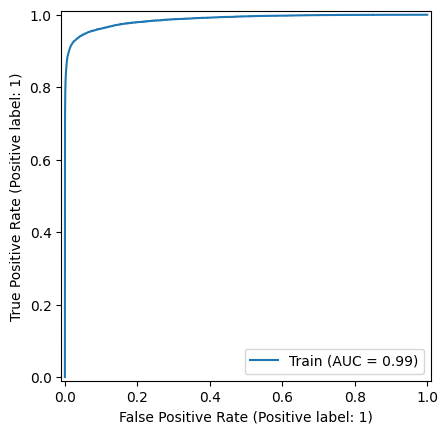

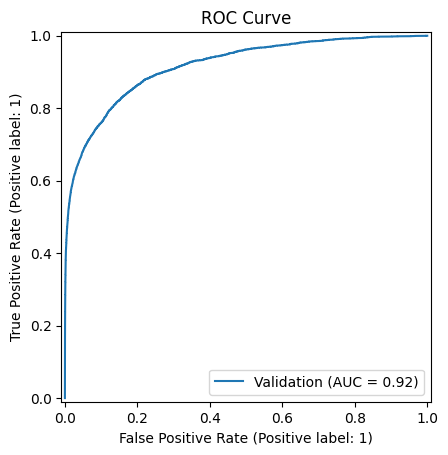

<Figure size 640x480 with 0 Axes>

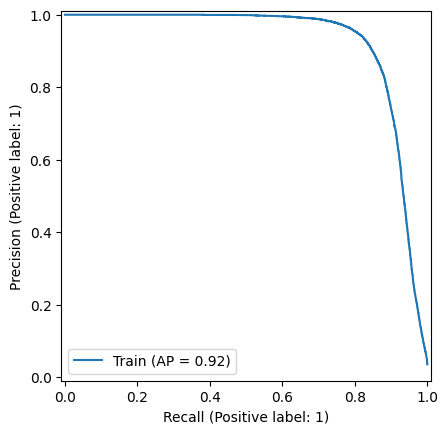

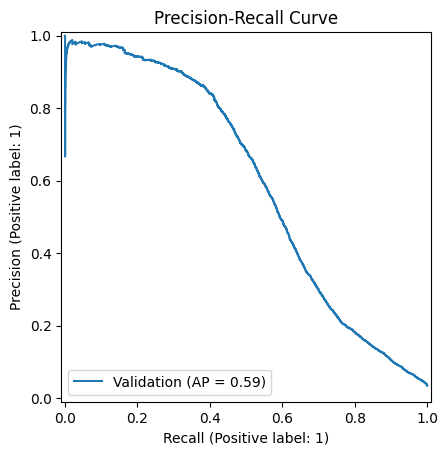

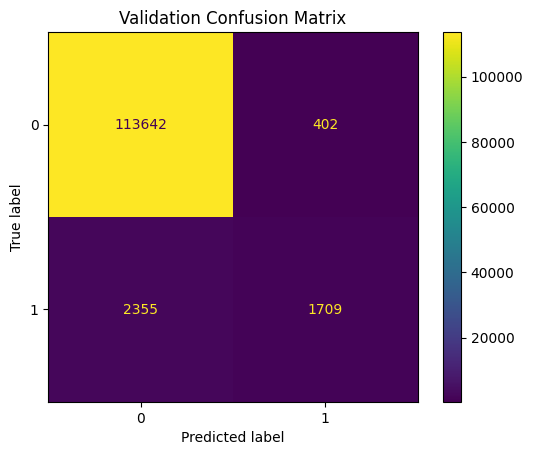

In [23]:
evaluate_catboost_model(catboost_model , x_train , y_train , x_val , y_val )